In [1]:


# import 'Pandas'
import pandas as pd

# import 'Numpy'
import numpy as np

# import subpackage of Matplotlib
import matplotlib.pyplot as plt

# import 'Seaborn'
import seaborn as sns

# to suppress warnings
from warnings import filterwarnings
filterwarnings('ignore')

# display all columns of the dataframe
pd.options.display.max_columns = None

# display all rows of the dataframe
pd.options.display.max_rows = None

# to display the float values upto 6 decimal places
pd.options.display.float_format = '{:.6f}'.format

# import train-test split
from sklearn.model_selection import train_test_split

# import various functions from statsmodels
import statsmodels
import statsmodels.api as sm

# import 'stats'
from scipy import stats

# 'metrics' from sklearn is used for evaluating the model performance
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error


# import function to perform linear regression
from sklearn.linear_model import LinearRegression

# import StandardScaler to perform scaling
from sklearn.preprocessing import StandardScaler

# import SGDRegressor from sklearn to perform linear regression with stochastic gradient descent
from sklearn.linear_model import SGDRegressor

# import function for ridge regression
from sklearn.linear_model import Ridge

# import function for lasso regression
from sklearn.linear_model import Lasso

# import function for elastic net regression
from sklearn.linear_model import ElasticNet

# import function to perform GridSearchCV
from sklearn.model_selection import GridSearchCV
plt.rcParams["figure.figsize"]=[15,8]

In [2]:
plt.rcParams["figure.figsize"]=[15,8]

In [3]:
ipl_df=pd.read_csv("ipl.csv")
ipl_df.head()

,PLAYER NAME,AGE,COUNTRY,PLAYING ROLE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,SOLD PRICE
0,Abdulla,2,South Africa,Allrounder,0,0,0,0.000000,0,0.000000,0,0,0,0.000000,0.000000,0,307,15,20.470000,9.900000,13.930000,50000
1,Abdur Razzak,2,Bangladesh,Bowler,266,18,657,71.410000,185,37.600000,0,0,0,0.000000,0.000000,0,29,0,0.000000,17.500000,0.000000,50000
2,Agarkar,2,India,Bowler,669,58,1269,80.620000,288,32.900000,0,167,39,18.560000,121.010000,5,1059,29,36.520000,8.810000,24.900000,350000
3,Ashwin,1,India,Bowler,308,31,241,84.560000,51,36.800000,0,58,11,5.800000,76.320000,0,1125,49,22.960000,8.230000,22.140000,850000
4,Badrinath,2,India,Batsman,109,0,79,45.930000,0,0.000000,0,1317,71,32.930000,120.710000,28,0,0,0.000000,1.000000,0.000000,800000


In [4]:
ipl_df1=ipl_df.copy()

In [5]:
ipl_df.dtypes

PLAYER NAME       object
AGE                int64
COUNTRY           object
PLAYING ROLE      object
T-RUNS             int64
T-WKTS             int64
ODI-RUNS-S         int64
ODI-SR-B         float64
ODI-WKTS           int64
ODI-SR-BL        float64
CAPTAINCY EXP      int64
RUNS-S             int64
HS                 int64
AVE              float64
SR-B             float64
SIXERS             int64
RUNS-C             int64
WKTS               int64
AVE-BL           float64
ECON             float64
SR-BL            float64
SOLD PRICE         int64
dtype: object

In [6]:
ipl_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   PLAYER NAME    130 non-null    object 
 1   AGE            130 non-null    int64  
 2   COUNTRY        130 non-null    object 
 3   PLAYING ROLE   130 non-null    object 
 4   T-RUNS         130 non-null    int64  
 5   T-WKTS         130 non-null    int64  
 6   ODI-RUNS-S     130 non-null    int64  
 7   ODI-SR-B       130 non-null    float64
 8   ODI-WKTS       130 non-null    int64  
 9   ODI-SR-BL      130 non-null    float64
 10  CAPTAINCY EXP  130 non-null    int64  
 11  RUNS-S         130 non-null    int64  
 12  HS             130 non-null    int64  
 13  AVE            130 non-null    float64
 14  SR-B           130 non-null    float64
 15  SIXERS         130 non-null    int64  
 16  RUNS-C         130 non-null    int64  
 17  WKTS           130 non-null    int64  
 18  AVE-BL    

In [7]:
ipl_df.duplicated().sum()

np.int64(0)

In [8]:
ipl_df.describe()

,AGE,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,CAPTAINCY EXP,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,SOLD PRICE
count,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000,130.000000
mean,2.092308,2220.569231,66.530769,2508.738462,71.185231,76.076923,34.033846,0.315385,514.492308,47.430769,18.719308,111.035615,17.692308,475.523077,17.107692,23.027154,7.689077,17.382615,521223.076923
std,0.576627,3304.509453,142.676855,3582.205625,25.912831,111.205070,26.751749,0.466466,615.582566,36.403624,11.094224,35.923843,23.828146,558.314049,21.822841,20.792672,5.245169,15.273422,406807.351419
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20000.000000
25%,2.000000,94.000000,0.000000,73.250000,65.632500,0.000000,0.000000,0.000000,39.000000,16.000000,9.825000,98.237500,1.000000,0.000000,0.000000,0.000000,3.000000,0.000000,225000.000000
50%,2.000000,624.500000,7.000000,835.000000,78.225000,18.500000,36.600000,0.000000,172.000000,35.500000,18.635000,118.510000,6.000000,297.000000,8.500000,24.605000,8.585000,19.935000,437500.000000
75%,2.000000,3061.000000,47.500000,3523.500000,86.790000,106.000000,45.325000,1.000000,925.250000,73.750000,27.872500,129.102500,29.750000,689.250000,23.750000,35.580000,10.255000,26.212500,700000.000000
max,3.000000,15530.000000,800.000000,18426.000000,116.660000,534.000000,150.000000,1.000000,2254.000000,158.000000,50.110000,235.490000,129.000000,1975.000000,83.000000,126.300000,39.110000,100.200000,1800000.000000


In [9]:
ipl_df.describe(include=object)

,PLAYER NAME,COUNTRY,PLAYING ROLE
count,130,130,130
unique,121,10,4
top,Sharma,India,Bowler
freq,3,53,44


In [10]:
ipl_df.drop(columns=["PLAYER NAME"],inplace=True)

In [11]:
ipl_df["AGE"]=ipl_df["AGE"].astype(object)

In [12]:
ipl_df["CAPTAINCY EXP"]=ipl_df["CAPTAINCY EXP"].astype(object)

In [13]:
ipl_df.dtypes

AGE               object
COUNTRY           object
PLAYING ROLE      object
T-RUNS             int64
T-WKTS             int64
ODI-RUNS-S         int64
ODI-SR-B         float64
ODI-WKTS           int64
ODI-SR-BL        float64
CAPTAINCY EXP     object
RUNS-S             int64
HS                 int64
AVE              float64
SR-B             float64
SIXERS             int64
RUNS-C             int64
WKTS               int64
AVE-BL           float64
ECON             float64
SR-BL            float64
SOLD PRICE         int64
dtype: object

In [14]:
Total=ipl_df.isnull().sum().sort_values(ascending=False)
Percent=(ipl_df.isnull().sum()*100/ipl_df.isnull().count()).sort_values(ascending=False)
missing_data=pd.concat([Total,Percent],axis=1,keys=["Toatal","Percentage of Missing Value"])
missing_data

,Toatal,Percentage of Missing Value
AGE,0,0.000000
COUNTRY,0,0.000000
PLAYING ROLE,0,0.000000
T-RUNS,0,0.000000
T-WKTS,0,0.000000
ODI-RUNS-S,0,0.000000
ODI-SR-B,0,0.000000
ODI-WKTS,0,0.000000
ODI-SR-BL,0,0.000000
CAPTAINCY EXP,0,0.000000


In [15]:
target_df=ipl_df["SOLD PRICE"]
feature_df=ipl_df.drop("SOLD PRICE",axis=1)

In [16]:
iplnum_cols=feature_df.select_dtypes(np.number)
iplcat_cols=feature_df.select_dtypes(object)
iplnum_cols.columns,iplcat_cols.columns

(Index(['T-RUNS', 'T-WKTS', 'ODI-RUNS-S', 'ODI-SR-B', 'ODI-WKTS', 'ODI-SR-BL',
        'RUNS-S', 'HS', 'AVE', 'SR-B', 'SIXERS', 'RUNS-C', 'WKTS', 'AVE-BL',
        'ECON', 'SR-BL'],
       dtype='object'),
 Index(['AGE', 'COUNTRY', 'PLAYING ROLE', 'CAPTAINCY EXP'], dtype='object'))

In [17]:
dummy_var=pd.get_dummies(data=iplcat_cols,drop_first=True,dtype=int)

In [18]:
dummy_var.head()

,AGE_2,AGE_3,COUNTRY_Bangladesh,COUNTRY_England,COUNTRY_India,COUNTRY_New Zealand,COUNTRY_Pakistan,COUNTRY_South Africa,COUNTRY_Sri Lanka,COUNTRY_West Indies,COUNTRY_Zimbabwe,PLAYING ROLE_Batsman,PLAYING ROLE_Bowler,PLAYING ROLE_W. Keeper,CAPTAINCY EXP_1
0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
4,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0


In [19]:
from sklearn.preprocessing import OneHotEncoder
ohe=OneHotEncoder()
ohe_encoder=ohe.fit_transform(iplcat_cols)
ohe_encoder=pd.DataFrame(ohe_encoder.toarray(),columns=ohe.get_feature_names_out())

In [20]:
ohe_encoder.head()

,AGE_1,AGE_2,AGE_3,COUNTRY_Australia,COUNTRY_Bangladesh,COUNTRY_England,COUNTRY_India,COUNTRY_New Zealand,COUNTRY_Pakistan,COUNTRY_South Africa,COUNTRY_Sri Lanka,COUNTRY_West Indies,COUNTRY_Zimbabwe,PLAYING ROLE_Allrounder,PLAYING ROLE_Batsman,PLAYING ROLE_Bowler,PLAYING ROLE_W. Keeper,CAPTAINCY EXP_0,CAPTAINCY EXP_1
0,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000
1,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
2,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
3,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000
4,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000


In [21]:
x_scaler=StandardScaler()
num_scaled=x_scaler.fit_transform(iplnum_cols)
num_scaled_df=pd.DataFrame(num_scaled,columns=iplnum_cols.columns)
y=(target_df-target_df.mean())/target_df.std()

In [22]:
x=pd.concat([num_scaled_df,dummy_var],axis=1)
x.head()

,T-RUNS,T-WKTS,ODI-RUNS-S,ODI-SR-B,ODI-WKTS,ODI-SR-BL,RUNS-S,HS,AVE,SR-B,SIXERS,RUNS-C,WKTS,AVE-BL,ECON,SR-BL,AGE_2,AGE_3,COUNTRY_Bangladesh,COUNTRY_England,COUNTRY_India,COUNTRY_New Zealand,COUNTRY_Pakistan,COUNTRY_South Africa,COUNTRY_Sri Lanka,COUNTRY_West Indies,COUNTRY_Zimbabwe,PLAYING ROLE_Batsman,PLAYING ROLE_Bowler,PLAYING ROLE_W. Keeper,CAPTAINCY EXP_1
0,-0.674581,-0.468108,-0.703043,-2.757731,-0.686760,-1.277132,-0.839014,-1.307954,-1.693829,-3.102818,-0.745369,-0.303010,-0.096956,-0.123459,0.423147,-0.226928,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0
1,-0.593774,-0.341460,-0.518927,0.008708,0.983269,0.133821,-0.839014,-1.307954,-1.693829,-3.102818,-0.745369,-0.802864,-0.786968,-1.111749,1.877704,-1.142498,1,0,1,0,0,0,0,0,0,0,0,0,1,0,0
2,-0.471347,-0.060022,-0.347421,0.365505,1.913068,-0.042548,-0.566677,-0.232487,-0.014415,0.278728,-0.534721,1.049112,0.547056,0.651433,0.214533,0.494091,1,0,0,0,1,0,0,0,0,0,0,0,1,0,0
3,-0.581015,-0.249993,-0.635505,0.518141,-0.226374,0.103801,-0.744430,-1.004617,-1.169012,-0.970105,-0.745369,1.167783,1.467072,-0.003242,0.103527,0.312686,0,0,0,0,1,0,0,0,0,0,0,0,1,0,0
4,-0.641468,-0.468108,-0.680904,-0.978393,-0.686760,-1.277132,1.308699,0.649946,1.285864,0.270344,0.434258,-0.855007,-0.786968,-1.111749,-1.280217,-1.142498,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0


In [23]:
import statsmodels.api as sm
x_train,y_train,x_test,y_test=train_test_split(x,y,random_state=10,test_size=0.2)

In [24]:
x_train,x_test,y_train,y_test = train_test_split(x,y,random_state=10,test_size=0.2)
print("x_train",x_train.shape)
print("y_train",y_train.shape)
print("x_test",x_test.shape)
print("y_test",y_test.shape)

x_train (104, 31)
y_train (104,)
x_test (26, 31)
y_test (26,)


In [25]:
# build a model on training dataset
# fit() is used to fit the OLS model
model = sm.OLS(y_train, x_train).fit()

# print the summary output
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:             SOLD PRICE   R-squared (uncentered):                   0.584
Model:                            OLS   Adj. R-squared (uncentered):              0.415
Method:                 Least Squares   F-statistic:                              3.464
Date:                Thu, 12 Feb 2026   Prob (F-statistic):                    7.47e-06
Time:                        10:17:41   Log-Likelihood:                         -104.49
No. Observations:                 104   AIC:                                      269.0
Df Residuals:                      74   BIC:                                      348.3
Df Model:                          30                                                  
Covariance Type:            nonrobust                                                  
                             coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------

In [26]:
def get_train_rmse(model):
    train_prd=model.predict(x_train)
    mse_train=mean_squared_error(y_train,train_prd)
    rmse_train=round(np.sqrt(mse_train),4)
    return(rmse_train)

In [27]:
def get_test_rmse(model):
    test_prd=model.predict(x_test)
    mse_test=mean_squared_error(y_test,test_prd)
    rmse_test=round(np.sqrt(mse_test),4)
    return(rmse_test)

In [28]:
def mape(actual,predicted):
    return (np.mean(np.abs((actual-predicted)/actual))*100)
def get_test_mape(model):
    test_pred=model.predict(x_test)
    mape_test=mape(y_test,test_pred)
    return(mape_test)

In [29]:
def get_score(model):
    r_sq=model.score(x_train,y_train)
    n=x_train.shape[0]
    k=x_train.shape[1]
    adj_r_sq=1-((1-r_sq)*(n-1)/(n-k-1))
    return([r_sq,adj_r_sq])

In [30]:
score_card=pd.DataFrame(columns=["Model_name","Alpha(Whenever Required)","l1-ratio","R-Squared",
                                 "Adj.R-Squared","Test_RMSE","Test_MAPE"])
def update_score_card(algorithm_name,model,alpha="-",l1_ratio="-"):
    global score_card
    score_card=score_card._append({"Model_name":algorithm_name,
                 "Alpha(Whenever Required)":alpha,
                 "l1-ratio":l1_ratio,
                 "R-Squared":get_score(model)[0],
                 "Adj.R-Squared":get_score(model)[1],
                 "Test_RMSE":get_test_rmse(model),
                 "Test_MAPE":get_test_mape(model)},ignore_index=True)

In [31]:
def plot_coefficients(model,algorithm_name):
    coef_df=pd.DataFrame({"Variable":x.columns,"Coefficient":model.coef_})
    sorted_coef=coef_df.sort_values("Coefficient",ascending=False)
    sns.barplot(x="Coefficient",y="Variable",data=sorted_coef)
    plt.xlabel("Coefficient from{}".format(algorithm_name),fontsize=15)
    plt.ylabel("Features",fontsize=15)

In [32]:
linreg=LinearRegression()
MLR_model=linreg.fit(x_train,y_train)
MLR_model.score(x_train,y_train)

0.5839698427213922

In [33]:
print("RMSE on train set",get_train_rmse(MLR_model))
print("RMSE on test set",get_test_rmse(MLR_model))
difference=abs(get_test_rmse(MLR_model)-get_train_rmse(MLR_model))
print("Difference between RMSE on Test and Train:",difference)

RMSE on train set 0.6609
RMSE on test set 0.8741
Difference between RMSE on Test and Train: 0.21319999999999995


In [34]:
update_score_card(algorithm_name="Linear Regression",model=MLR_model)
score_card

,Model_name,Alpha(Whenever Required),l1-ratio,R-Squared,Adj.R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.583970,0.404846,0.874100,235.410142


In [35]:
sgd=SGDRegressor(random_state=10)
linreg_with_SGD=sgd.fit(x_train,y_train)
print("RMSE on Train set : ",get_train_rmse(linreg_with_SGD))
print("RMSE on Test set : ",get_test_rmse(linreg_with_SGD))

RMSE on Train set :  0.7176
RMSE on Test set :  0.8166


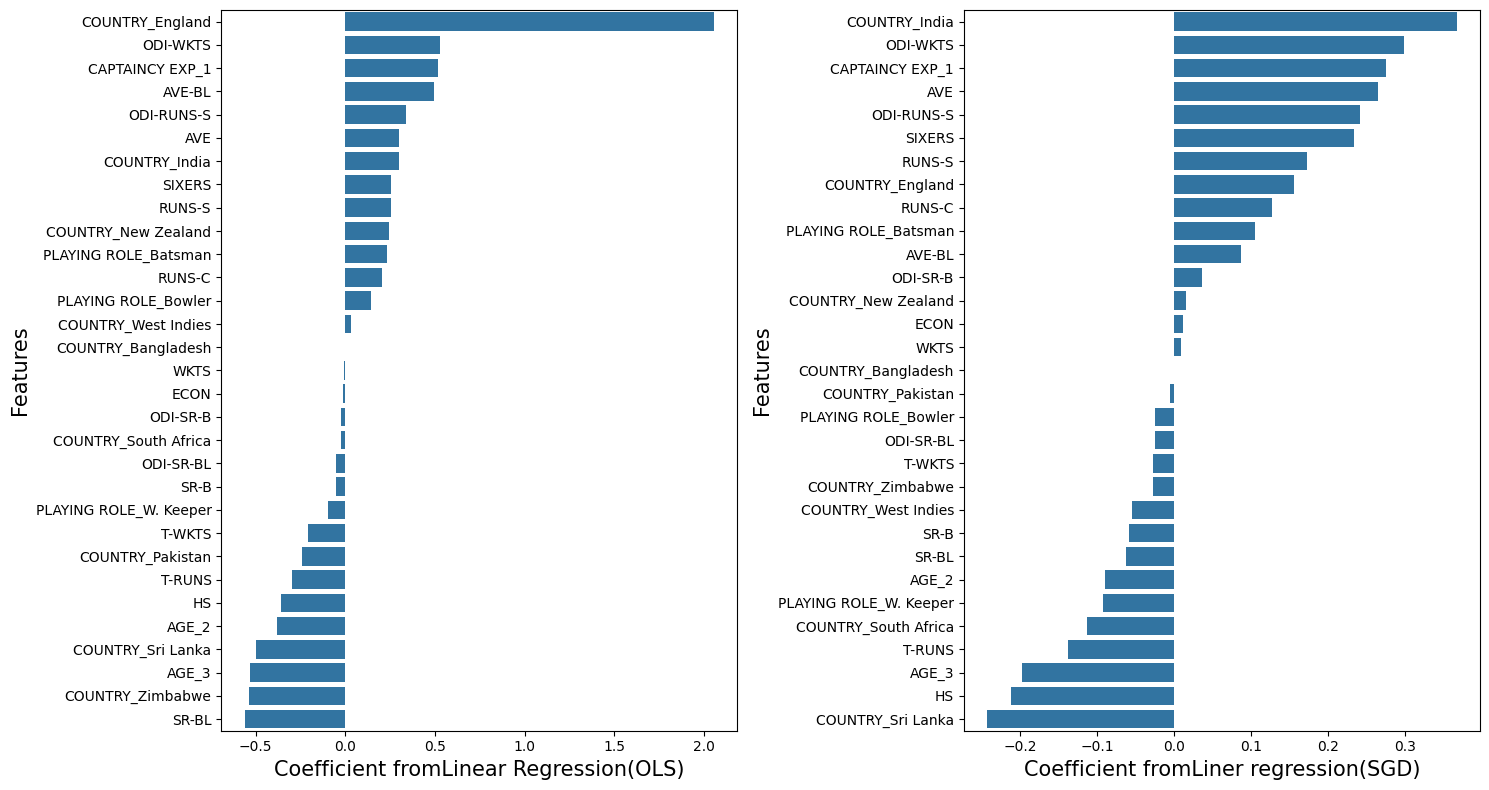

In [36]:
plt.subplot(1,2,1)
plot_coefficients(MLR_model,"Linear Regression(OLS)")
plt.subplot(1,2,2)
plot_coefficients(linreg_with_SGD,"Liner regression(SGD)")
plt.tight_layout()
plt.show()

In [37]:
update_score_card(algorithm_name="Linear Regression(SGD)",model=linreg_with_SGD)
score_card

,Model_name,Alpha(Whenever Required),l1-ratio,R-Squared,Adj.R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.583970,0.404846,0.874100,235.410142
1,Linear Regression(SGD),-,-,0.509495,0.298306,0.816600,175.609553


In [38]:
ridge=Ridge(alpha=1,max_iter=500)
ridge.fit(x_train,y_train)
print("RMSE of Ridge on Test set :",get_test_rmse(ridge))

RMSE of Ridge on Test set : 0.8438


In [39]:
update_score_card(algorithm_name="Ridge Regression(with alpha = 1)",model=ridge,alpha=1)
score_card

,Model_name,Alpha(Whenever Required),l1-ratio,R-Squared,Adj.R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.583970,0.404846,0.874100,235.410142
1,Linear Regression(SGD),-,-,0.509495,0.298306,0.816600,175.609553
2,Ridge Regression(with alpha = 1),1,-,0.571239,0.386633,0.843800,251.847441


In [40]:
ridge=Ridge(alpha=2,max_iter=500)
ridge.fit(x_train,y_train)
print("RMSE of Ridge on Test set :",get_test_rmse(ridge))

RMSE of Ridge on Test set : 0.8367


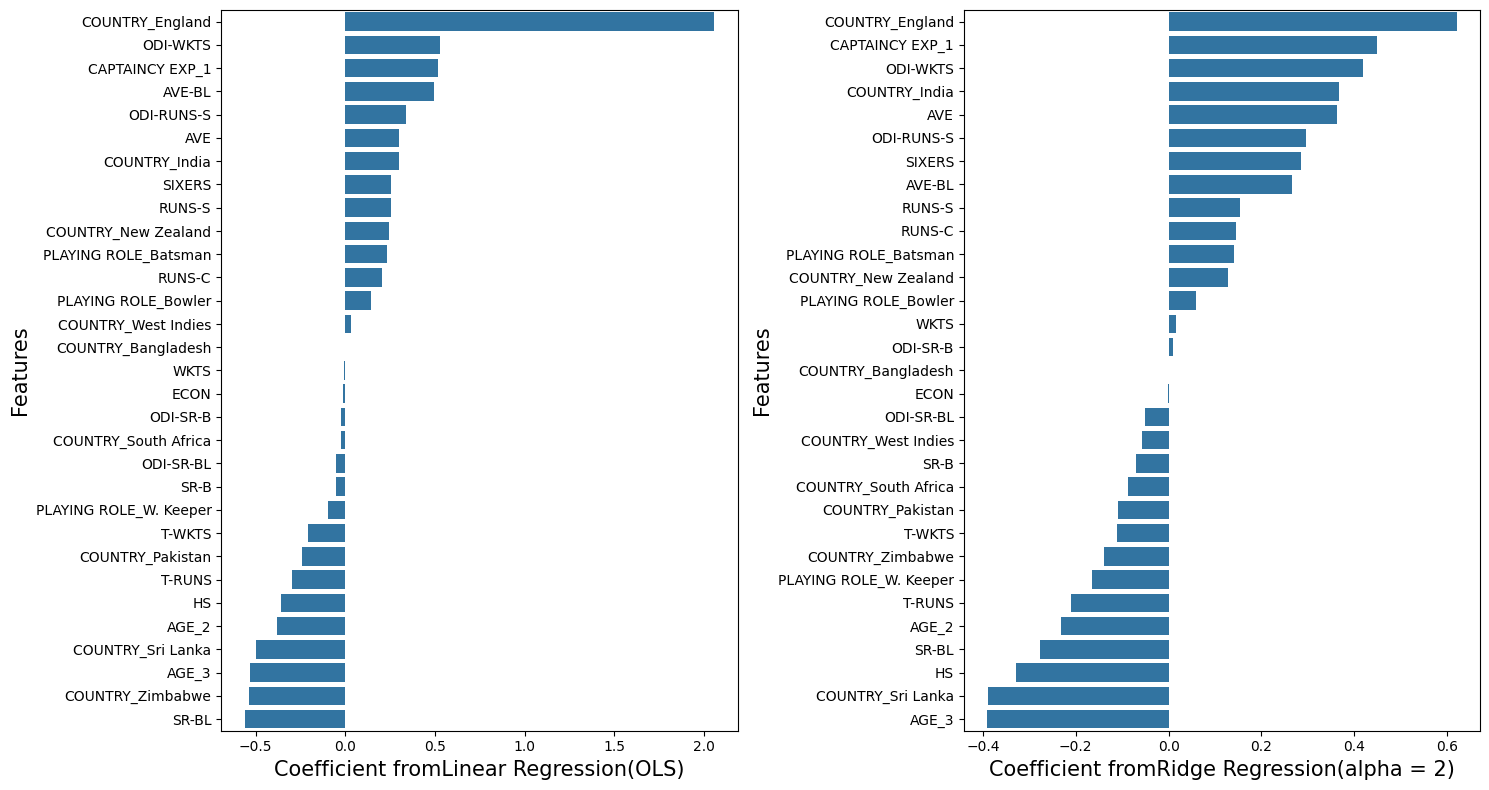

In [41]:
plt.subplot(1,2,1)
plot_coefficients(MLR_model,"Linear Regression(OLS)")
plt.subplot(1,2,2)
plot_coefficients(ridge,"Ridge Regression(alpha = 2)")
plt.tight_layout()
plt.show()

In [42]:
update_score_card(algorithm_name="Ridge Regression(with alpha = 2)",model=ridge,alpha=2)
score_card

,Model_name,Alpha(Whenever Required),l1-ratio,R-Squared,Adj.R-Squared,Test_RMSE,Test_MAPE
0,Linear Regression,-,-,0.583970,0.404846,0.874100,235.410142
1,Linear Regression(SGD),-,-,0.509495,0.298306,0.816600,175.609553
2,Ridge Regression(with alpha = 1),1,-,0.571239,0.386633,0.843800,251.847441
3,Ridge Regression(with alpha = 2),2,-,0.559474,0.369803,0.836700,238.397687
